In [61]:
import sys
import scipy as sc
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from cmcrameri import cm

sys.path.append("code/analysis/utils")
from averages import compute_pdf_from_bins

font = {'size':14}
mpl.rc("font", **font)

In [114]:
A_projected = np.random.gamma(12, scale=0.09, size=1000000)
A_basal     = np.random.gamma(12, scale=0.09, size=1000000)
A_arr       = np.linspace(A_projected.min(), A_projected.max(), 100)

mask = A_basal > 0 #(np.log(A_projected) > -0.5) * (np.log(A_basal) > -0.5)
a           = (A_basal / A_projected)
V_measured  = (3*1 / (1 + np.sqrt(a) + a))[mask]
h_measured  = (3*1 / ((1 + np.sqrt(a) + a)*A_projected))[mask]
A_projected = A_projected[mask]

In [ ]:
xA, yA = compute_pdf_from_bins(A_projected, 20, 0)
xh, yh = compute_pdf_from_bins(h_measured, 20, 0)
xV, yV = compute_pdf_from_bins(V_measured, 20, 0)

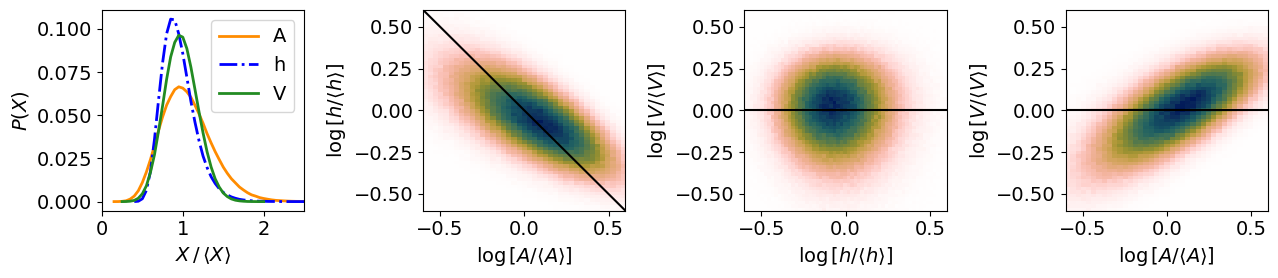

In [118]:
fig, ax = plt.subplots(1,4, figsize=(13, 3))

ax[0].plot(xA, yA, "-",  c="darkorange", lw=2, label="A")
ax[0].plot(xh, yh, '-.', c="b", lw=2, label="h")
ax[0].plot(xV, yV, '-',  c="forestgreen", lw=2, label="V")
ax[0].set(xlabel=r"$X\,/\,\langle X \rangle$",
            ylabel=r"$P(X)$",
            xlim=(0, 2.5))
ax[0].legend()



ax[1].hist2d(np.log(A_projected.ravel()),
               np.log(h_measured.ravel()), bins=[96, 96], cmap=cm.batlowW_r)
ax[2].hist2d(np.log(h_measured.ravel()),
               np.log(V_measured.ravel()), bins=[96, 96], cmap=cm.batlowW_r)
ax[3].hist2d(np.log(A_projected.ravel()),
               np.log(V_measured.ravel()), bins=[96, 96], cmap=cm.batlowW_r)

ax[1].set(ylabel=r"$\log{[h/\langle h \rangle]}$", 
            xlabel=r"$\log{[A/\langle A \rangle]}$")

ax[2].set(ylabel=r"$\log{[V/\langle V \rangle]}$", 
            xlabel=r"$\log{[h/\langle h \rangle]}$")

ax[3].set(xlabel=r"$\log{[A/\langle A \rangle]}$", 
            ylabel=r"$\log{[V/\langle V \rangle]}$")

ax[1].plot(np.log(1/A_arr), np.log(A_arr), 'k-')
ax[2].plot(np.log(1/A_arr), np.zeros_like(A_arr), 'k-')
ax[3].plot(np.log(A_arr),   np.zeros_like(A_arr), 'k-')

for ax_i in ax.flatten()[1:]:
    ax_i.set(xlim=[-.6,.6],
             ylim=[-.6,.6])

fig.tight_layout()
# fig.savefig("figs/paper/frustum_distributions.png", dpi=300)

In [119]:
corr_coeffs_hA = sc.stats.pearsonr(A_projected, h_measured)[0]
corr_coeffs_hV = sc.stats.pearsonr(V_measured,  h_measured)[0]
corr_coeffs_AV = sc.stats.pearsonr(V_measured,  A_projected)[0]

print(corr_coeffs_hA)
print(corr_coeffs_hV)
print(corr_coeffs_AV)

-0.6756822421272609
0.002632990070003879
0.6924450944427918


In [66]:
A_projected = np.random.gamma(17, scale=0.06, size=1000000)
A_basal     = np.random.gamma(17, scale=0.06, size=1000000)
A_midpoint  = np.random.gamma(17, scale=0.06, size=1000000)

V_measured  = (6*1 / (1 + 4*A_midpoint / A_projected + A_basal / A_projected))
h_measured  = (6*1 / (A_projected + 4*A_midpoint + A_basal))
A_projected = A_projected

In [67]:
xA, yA = compute_pdf_from_bins(A_projected, 20, 0)
xM, yM = compute_pdf_from_bins(A_midpoint, 20, 0)
xh, yh = compute_pdf_from_bins(h_measured, 20, 0)
xV, yV = compute_pdf_from_bins(V_measured, 20, 0)

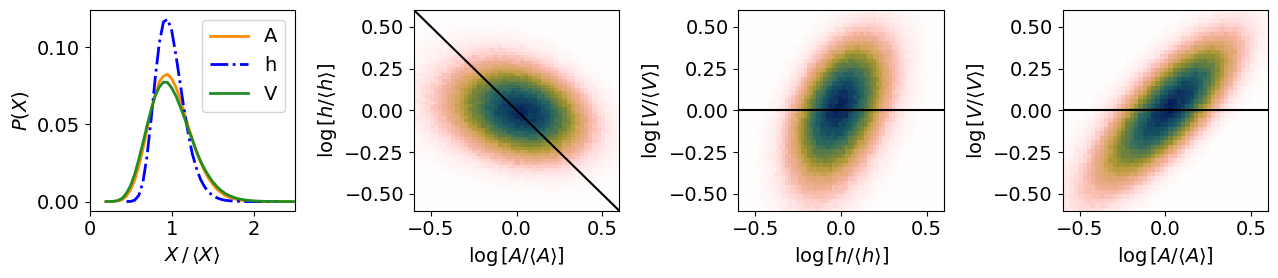

In [68]:
fig, ax = plt.subplots(1,4, figsize=(13, 3))

ax[0].plot(xA, yA, "-",  c="darkorange", lw=2, label="A")
ax[0].plot(xh, yh, '-.', c="b", lw=2, label="h")
ax[0].plot(xV, yV, '-',  c="forestgreen", lw=2, label="V")
ax[0].set(xlabel=r"$X\,/\,\langle X \rangle$",
            ylabel=r"$P(X)$",
            xlim=(0, 2.5))
ax[0].legend()



ax[1].hist2d(np.log(A_projected.ravel()),
               np.log(h_measured.ravel()), bins=[96, 96], cmap=cm.batlowW_r)
ax[2].hist2d(np.log(h_measured.ravel()),
               np.log(V_measured.ravel()), bins=[96, 96], cmap=cm.batlowW_r)
ax[3].hist2d(np.log(A_projected.ravel()),
               np.log(V_measured.ravel()), bins=[96, 96], cmap=cm.batlowW_r)

ax[1].set(ylabel=r"$\log{[h/\langle h \rangle]}$", 
            xlabel=r"$\log{[A/\langle A \rangle]}$")

ax[2].set(ylabel=r"$\log{[V/\langle V \rangle]}$", 
            xlabel=r"$\log{[h/\langle h \rangle]}$")

ax[3].set(xlabel=r"$\log{[A/\langle A \rangle]}$", 
            ylabel=r"$\log{[V/\langle V \rangle]}$")

ax[1].plot(np.log(1/A_arr), np.log(A_arr), 'k-')
ax[2].plot(np.log(1/A_arr), np.zeros_like(A_arr), 'k-')
ax[3].plot(np.log(A_arr),   np.zeros_like(A_arr), 'k-')

for ax_i in ax.flatten()[1:]:
    ax_i.set(xlim=[-.6,.6],
             ylim=[-.6,.6])
    
    # ax_i.spines.right.set_visible(False)
    # ax_i.spines.top.set_visible(False)
    


fig.tight_layout()
fig.savefig("figs/paper/prismatoid_distributions.png", dpi=300)

In [69]:
corr_coeffs_hA = sc.stats.pearsonr(A_projected, h_measured)[0]
corr_coeffs_hV = sc.stats.pearsonr(V_measured,  h_measured)[0]
corr_coeffs_AV = sc.stats.pearsonr(V_measured,  A_projected)[0]

print(corr_coeffs_hA)
print(corr_coeffs_hV)
print(corr_coeffs_AV)

-0.24024325846338399
0.4267913310122124
0.7610406627667579
